## Import data and rename columns

In [277]:
import numpy as np
import pandas as pd
import os
pd.set_option("display.max_columns", None)

# PUT GITHUB ROOT PATH HERE
root_dir = "/Users/albert/Library/CloudStorage/OneDrive-andrew.cmu.edu/Documents/CMU 26-27/Undergraduate Research/Victimization/Code/capstone_victimization"
dir = root_dir + "/Data and Resources/raw_data"
os.chdir(dir)

In [278]:
raw_data = pd.read_csv(os.path.join(dir, "FINAL.csv"))
print(raw_data.shape[0])
print(raw_data.shape[1])

8984
380


In [279]:
"""
Rename NLSY97 columns from raw reference numbers (e.g. "R0536300") to
human-readable names, using the question titles in the .cdb codebook.

Usage:
    import pandas as pd
    from rename_columns import build_rename_map

    raw_data = pd.read_csv("FINALDATA.csv")          # your raw extract
    rename_map = build_rename_map("FINALDATA.cdb")    # parse the codebook
    data = raw_data.rename(columns=rename_map)
"""
import re


# =====================================================================
# STEP 1 — parse the .cdb codebook into one record per variable
# =====================================================================

def parse_cdb(cdb_path):
    """
    Parses an NLS Investigator .cdb codebook into a list of dicts:
        {"column": ..., "refnum": ..., "varname": ..., "year": ..., "title": ...}

    - "refnum"  : the codebook reference number, e.g. "R05363.00"
    - "column"  : the actual dataframe column name, which is the refnum with
                  the decimal point removed, e.g. "R0536300" (this is how
                  NLS Investigator extracts name their CSV/dat columns)
    - "varname" : the short bracketed variable name, e.g. "KEY!SEX"
    - "year"    : the survey year the question was asked in ("XRND" for
                  variables that aren't tied to one specific round)
    - "title"   : the human-readable question title, e.g.
                  "1997 COLLEGE: R ENROLLMENT STATUS IN MONTH 01"
    """
    with open(cdb_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()
    text = text.replace("\r\n", "\n")  # the file uses CRLF line endings

    blocks = text.split("-" * 80)

    header_re = re.compile(
        r"^\s*(?P<refnum>\S+)\s+\[(?P<varname>[^\]]+)\]\s+Survey Year:\s*(?P<year>\S+)"
    )

    records = []
    for block in blocks:
        lines = block.strip("\n").split("\n")
        if not lines or not lines[0].strip():
            continue
        m = header_re.match(lines[0])
        if not m:
            continue

        refnum = m.group("refnum")
        column = refnum.replace(".", "")

        # The title is the first non-blank line after the "PRIMARY VARIABLE"
        # tag (skipped if present), ending at the next blank line.
        body = lines[1:]
        i = 0
        if i < len(body) and "PRIMARY VARIABLE" in body[i]:
            i += 1
        while i < len(body) and not body[i].strip():
            i += 1
        title_lines = []
        while i < len(body) and body[i].strip():
            title_lines.append(body[i].strip())
            i += 1

        records.append({
            "column": column,
            "refnum": refnum,
            "varname": m.group("varname"),
            "year": m.group("year"),
            "title": " ".join(title_lines).strip(),
        })

    return records


# =====================================================================
# STEP 2 — turn a question title into a clean snake_case name
# =====================================================================

def slugify(text, max_words=10):
    text = text.lower()
    text = re.sub(r"\(.*?\)", " ", text)        # drop parenthetical asides, e.g. "(HEALTH)"
    text = re.sub(r"[^a-z0-9]+", "_", text)      # non-alphanumeric -> underscore
    text = re.sub(r"_+", "_", text).strip("_")
    words = text.split("_")
    return "_".join(words[:max_words])


# =====================================================================
# STEP 3 — hand-picked names for the columns worth naming precisely
# =====================================================================
# Anything not listed here gets an auto-generated name from its title
# (STEP 4). Add to this dict for any variable where the auto-slugified
# title would be misleading, too long, or you just want a specific name.

MANUAL_OVERRIDES = {
    "R0000100": "respondent_id",
    "R0536300": "sex",
    "R0536401": "birth_month",
    "R0536402": "birth_year",
    "R0536600": "current_age_1997",
    "R0536700": "age_dec31_1996",
    "R1204700": "household_net_worth",
    "R1235800": "sample_type",
    "R1302400": "biological_father_education",
    "R1302500": "biological_mother_education",
    "R1482600": "race_ethnicity_survey",
    "R0538700": "race",
    "R0538600": "ethnicity",


    "S1242700": "violent_victim_2002",
    "S1242800": "age_at_violent_victimization_2002",
    "T1064700": "violent_victim_2007",
    "T1064800": "age_at_violent_victimization_2007",
    "T3158400": "violent_victim_2008",
    "T3158500": "age_at_violent_victimization_2008",
    "T4576400": "violent_victim_2009",
    "T4576500": "age_at_violent_victimization_2009",
    "T9107600": "violent_victim_2013",
    "T9107700": "age_at_violent_victimization_2013",

    # a few titles where the auto-slugified version loses meaning
    # (truncation drops the final word, or strips a "<" that mattered)
    "R0444000": "bullying_victim_before_age_12",
    "Z0442300": "lived_with_both_bio_parents_at_birth",
}

# Monthly college-status columns (E511YYMM) are named programmatically from
# the varname, e.g. "SCH_COLLEGE_STATUS_1997.01" -> "college_status_1997_01",
# rather than from the (much wordier) title. This also keeps them sorted
# and easy to pattern-match later if needed.
COLLEGE_STATUS_RE = re.compile(r"^SCH_COLLEGE_STATUS_(\d{4})\.(\d{2})$")


# =====================================================================
# STEP 4 — build the full rename map
# =====================================================================

def build_rename_map(cdb_path, verbose=True):
    records = parse_cdb(cdb_path)

    rename_map = {}
    used_names = set()

    def make_unique(name, column):
        # If two variables would slugify to the same name, disambiguate
        # with the year, then (last resort) the original column code.
        if name not in used_names:
            return name
        rec_year = next((r["year"] for r in records if r["column"] == column), None)
        if rec_year and rec_year != "XRND":
            candidate = f"{name}_{rec_year}"
            if candidate not in used_names:
                return candidate
        return f"{name}_{column.lower()}"

    for r in records:
        col = r["column"]

        if col in MANUAL_OVERRIDES:
            name = MANUAL_OVERRIDES[col]
        else:
            m = COLLEGE_STATUS_RE.match(r["varname"])
            if m:
                year, month = m.groups()
                name = f"college_status_{year}_{month}"
            else:
                name = slugify(r["title"]) or slugify(r["varname"]) or col.lower()

        name = make_unique(name, col)
        used_names.add(name)
        rename_map[col] = name

    if verbose:
        print(f"parsed {len(records)} variables from codebook")
        print(f"built {len(rename_map)} renames "
              f"({len(MANUAL_OVERRIDES)} manual, {len(rename_map) - len(MANUAL_OVERRIDES)} auto)")
        n_dupe_check = len(set(rename_map.values()))
        print(f"unique new names: {n_dupe_check} / {len(rename_map)}  "
              f"({'OK, no collisions' if n_dupe_check == len(rename_map) else 'COLLISION - check output'})")

    return rename_map

In [280]:
rename_map = build_rename_map(os.path.join(dir, "FINAL.cdb"))

print("\nsample of the mapping:")
for col in list(rename_map):
    print(f"  {col:10s} -> {rename_map[col]}")

parsed 380 variables from codebook
built 380 renames (25 manual, 355 auto)
unique new names: 380 / 380  (OK, no collisions)

sample of the mapping:
  E5111701   -> college_status_1997_01
  E5111702   -> college_status_1997_02
  E5111703   -> college_status_1997_03
  E5111704   -> college_status_1997_04
  E5111705   -> college_status_1997_05
  E5111706   -> college_status_1997_06
  E5111707   -> college_status_1997_07
  E5111708   -> college_status_1997_08
  E5111709   -> college_status_1997_09
  E5111710   -> college_status_1997_10
  E5111711   -> college_status_1997_11
  E5111712   -> college_status_1997_12
  E5111801   -> college_status_1998_01
  E5111802   -> college_status_1998_02
  E5111803   -> college_status_1998_03
  E5111804   -> college_status_1998_04
  E5111805   -> college_status_1998_05
  E5111806   -> college_status_1998_06
  E5111807   -> college_status_1998_07
  E5111808   -> college_status_1998_08
  E5111809   -> college_status_1998_09
  E5111810   -> college_status_19

In [281]:
print(rename_map)

{'E5111701': 'college_status_1997_01', 'E5111702': 'college_status_1997_02', 'E5111703': 'college_status_1997_03', 'E5111704': 'college_status_1997_04', 'E5111705': 'college_status_1997_05', 'E5111706': 'college_status_1997_06', 'E5111707': 'college_status_1997_07', 'E5111708': 'college_status_1997_08', 'E5111709': 'college_status_1997_09', 'E5111710': 'college_status_1997_10', 'E5111711': 'college_status_1997_11', 'E5111712': 'college_status_1997_12', 'E5111801': 'college_status_1998_01', 'E5111802': 'college_status_1998_02', 'E5111803': 'college_status_1998_03', 'E5111804': 'college_status_1998_04', 'E5111805': 'college_status_1998_05', 'E5111806': 'college_status_1998_06', 'E5111807': 'college_status_1998_07', 'E5111808': 'college_status_1998_08', 'E5111809': 'college_status_1998_09', 'E5111810': 'college_status_1998_10', 'E5111811': 'college_status_1998_11', 'E5111812': 'college_status_1998_12', 'E5111901': 'college_status_1999_01', 'E5111902': 'college_status_1999_02', 'E5111903':

In [282]:
data = raw_data.rename(columns=rename_map)
data.head()

,college_status_1997_01,college_status_1997_02,college_status_1997_03,college_status_1997_04,college_status_1997_05,college_status_1997_06,college_status_1997_07,college_status_1997_08,college_status_1997_09,college_status_1997_10,college_status_1997_11,college_status_1997_12,college_status_1998_01,college_status_1998_02,college_status_1998_03,college_status_1998_04,college_status_1998_05,college_status_1998_06,college_status_1998_07,college_status_1998_08,college_status_1998_09,college_status_1998_10,college_status_1998_11,college_status_1998_12,college_status_1999_01,college_status_1999_02,college_status_1999_03,college_status_1999_04,college_status_1999_05,college_status_1999_06,college_status_1999_07,college_status_1999_08,college_status_1999_09,college_status_1999_10,college_status_1999_11,college_status_1999_12,college_status_2000_01,college_status_2000_02,college_status_2000_03,college_status_2000_04,college_status_2000_05,college_status_2000_06,college_status_2000_07,college_status_2000_08,college_status_2000_09,college_status_2000_10,college_status_2000_11,college_status_2000_12,college_status_2001_01,college_status_2001_02,college_status_2001_03,college_status_2001_04,college_status_2001_05,college_status_2001_06,college_status_2001_07,college_status_2001_08,college_status_2001_09,college_status_2001_10,college_status_2001_11,college_status_2001_12,college_status_2002_01,college_status_2002_02,college_status_2002_03,college_status_2002_04,college_status_2002_05,college_status_2002_06,college_status_2002_07,college_status_2002_08,college_status_2002_09,college_status_2002_10,college_status_2002_11,college_status_2002_12,college_status_2003_01,college_status_2003_02,college_status_2003_03,college_status_2003_04,college_status_2003_05,college_status_2003_06,college_status_2003_07,college_status_2003_08,college_status_2003_09,college_status_2003_10,college_status_2003_11,college_status_2003_12,college_status_2004_01,college_status_2004_02,college_status_2004_03,college_status_2004_04,college_status_2004_05,college_status_2004_06,college_status_2004_07,college_status_2004_08,college_status_2004_09,college_status_2004_10,college_status_2004_11,college_status_2004_12,college_status_2005_01,college_status_2005_02,college_status_2005_03,college_status_2005_04,college_status_2005_05,college_status_2005_06,college_status_2005_07,college_status_2005_08,college_status_2005_09,college_status_2005_10,college_status_2005_11,college_status_2005_12,college_status_2006_02,college_status_2006_03,college_status_2006_04,college_status_2006_05,college_status_2006_06,college_status_2006_07,college_status_2006_08,college_status_2006_09,college_status_2006_10,college_status_2006_11,college_status_2006_12,college_status_2007_01,college_status_2007_02,college_status_2007_03,college_status_2007_04,college_status_2007_05,college_status_2007_06,college_status_2007_07,college_status_2007_08,college_status_2007_09,college_status_2007_10,college_status_2007_11,college_status_2007_12,college_status_2008_01,college_status_2008_02,college_status_2008_03,college_status_2008_04,college_status_2008_05,college_status_2008_06,college_status_2008_07,college_status_2008_08,college_status_2008_09,college_status_2008_10,college_status_2008_11,college_status_2008_12,college_status_2009_01,college_status_2009_02,college_status_2009_03,college_status_2009_04,college_status_2009_05,college_status_2009_06,college_status_2009_07,college_status_2009_08,college_status_2009_09,college_status_2009_10,college_status_2009_11,college_status_2009_12,college_status_2010_01,college_status_2010_02,college_status_2010_03,college_status_2010_04,college_status_2010_05,college_status_2010_06,college_status_2010_07,college_status_2010_08,college_status_2010_09,college_status_2010_10,college_status_2010_11,college_status_2010_12,college_status_2011_01,college_status_2011_02,college_status_2011_03,college_status_2011_04,college_status_2011_05,college_status_2011_06,college_status_2011_

## Create treatment (timely college entrance)

In [283]:
# Temporary plotting helper
import re
import matplotlib.pyplot as plt

def labeled_bar(summary, title, ylabel="Number of respondents", figsize=(9, 5)):
    # Bar chart of a Series of counts with "count (pct)" labels.
    # Float cast avoids int(NaN) errors when a reindexed category is empty.
    total = float(np.nansum(summary.values))
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(range(len(summary)), summary.fillna(0).values)
    for i, v in enumerate(summary.values):
        v = 0 if pd.isna(v) else float(v)
        ax.text(i, v, f"{int(v):,}\n({v / total * 100:.1f}%)" if total else "0",
                ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(summary)))
    ax.set_xticklabels(summary.index, rotation=0, fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.margins(y=0.18)
    plt.tight_layout()
    plt.show()

In [284]:
# ============================================================
# COLLEGE HISTORY — full monthly panel (all available months)
# ============================================================
# Monthly enrollment columns are now named college_status_YYYY_MM
# after the rename (e.g. college_status_1997_01 = Jan 1997), so the
# panel is built directly from `data` instead of the raw E511YYMM codes.

monthly_code_re = re.compile(r"^college_status_(\d{4})_(\d{2})$")
monthly_codes = {}
for c in data.columns:
    m = monthly_code_re.match(c)
    if m:
        monthly_codes[c] = (int(m.group(1)), int(m.group(2)))

print(f"monthly enrollment columns found : {len(monthly_codes):,}")
print(f"year range                       : "
      f"{min(y for y, _ in monthly_codes.values())}-{max(y for y, _ in monthly_codes.values())}")
months_per_year = pd.Series(
    [y for y, _ in monthly_codes.values()]).value_counts().sort_index()

college_vars = (
    data[["respondent_id"] + list(monthly_codes)]
    .melt(id_vars="respondent_id", var_name="code", value_name="college_status")
)

college_vars["year"] = college_vars["code"].map({c: v[0] for c, v in monthly_codes.items()})
college_vars["month"] = college_vars["code"].map({c: v[1] for c, v in monthly_codes.items()})
college_vars = college_vars.drop(columns="code")

# Attach birth date to compute age at each monthly observation
college_vars = college_vars.merge(
    data[["respondent_id", "birth_month", "birth_year"]],
    on="respondent_id", how="left",
)

# Month-precision age (ignores day of birth, so accurate to within one month)
college_vars["age"] = (
    college_vars["year"]
    - college_vars["birth_year"]
    - (college_vars["month"] < college_vars["birth_month"]).astype(int)
)

# Single monotone integer for ordering across year boundaries
college_vars["college_time"] = college_vars["year"] * 12 + college_vars["month"]

# Status flags
#   1 = not enrolled, 2 = 2-yr college, 3 = 4-yr college, 4 = graduate program
college_vars["valid_status"]     = college_vars["college_status"].isin([1, 2, 3, 4])
college_vars["enrolled_college"] = college_vars["college_status"].isin([2, 3])
college_vars["grad_status"]      = college_vars["college_status"].eq(4)
college_vars["not_enrolled"]     = college_vars["college_status"].eq(1)

print(f"\npanel rows                       : {len(college_vars):,}")
print(f"respondents                      : {college_vars['respondent_id'].nunique():,}")
print(f"valid status observations        : {college_vars['valid_status'].sum():,}")

monthly enrollment columns found : 332
year range                       : 1997-2024

panel rows                       : 2,982,688
respondents                      : 8,984
valid status observations        : 2,589,984


In [285]:
# ============================================================
# COLLEGE HISTORY CLASSIFICATION
# ============================================================

college_history = (
    college_vars
    .groupby("respondent_id")
    .agg(
        has_valid_college_info=("valid_status", "any"),
        ever_enrolled=("enrolled_college", "any"),     # 2-yr or 4-yr only
        ever_grad=("grad_status", "any"),              # graduate program
    )
    .reset_index()
)

COLLEGE_HISTORY_ORDER = [
    "Enrolled",
    "Never observed enrolled",
    "Grad program only",
    "Unknown",
]

college_history["college_history"] = np.select(
    [
        ~college_history["has_valid_college_info"],
        college_history["ever_enrolled"],
        college_history["ever_grad"] & ~college_history["ever_enrolled"],
    ],
    [
        "Unknown",
        "Enrolled",
        "Grad program only",
    ],
    default="Never observed enrolled",
)

print(college_history["college_history"].value_counts().reindex(
    COLLEGE_HISTORY_ORDER, fill_value=0).to_string())
print()
print(f"'Grad program only' = attended college but never observed in a 2-yr/4-yr program.")
print(f"These are NOT controls (treatment definition below sets their treatment to NaN): "
      f"{(college_history['college_history'] == 'Grad program only').sum():,}")

college_history
Enrolled                   5918
Never observed enrolled    3059
Grad program only             7
Unknown                       0

'Grad program only' = attended college but never observed in a 2-yr/4-yr program.
These are NOT controls (treatment definition below sets their treatment to NaN): 7


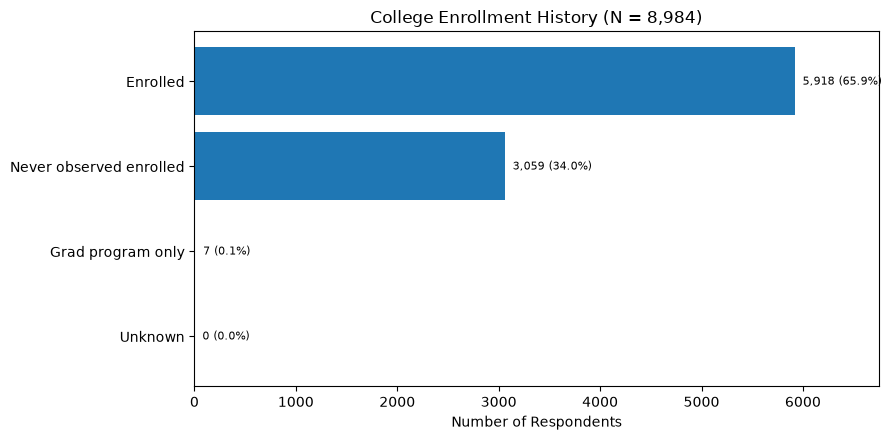

In [286]:
# ============================================================
# PLOT: COLLEGE HISTORY
# ============================================================

college_counts = (
    college_history["college_history"]
    .value_counts()
    .reindex(COLLEGE_HISTORY_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(college_counts)), college_counts.values)
ax.set_yticks(range(len(college_counts)))
ax.set_yticklabels(college_counts.index)
ax.invert_yaxis()

total = college_counts.sum()
for i, v in enumerate(college_counts.values):
    ax.text(v, i, f"  {v:,} ({v / total * 100:.1f}%)", va="center", fontsize=8)

ax.set_title(f"College Enrollment History (N = {total:,})")
ax.set_xlabel("Number of Respondents")
ax.margins(x=0.14)
plt.tight_layout()
plt.show()

In [287]:
# ============================================================
# FIRST OBSERVED COLLEGE ENROLLMENT (from all months)
# ============================================================

first_college = (
    college_vars[college_vars["enrolled_college"]]
    .sort_values(["respondent_id", "college_time"])
    .drop_duplicates("respondent_id", keep="first")
    [["respondent_id", "year", "month", "age", "college_time"]]
    .rename(columns={
        "year": "first_college_year",
        "month": "first_college_month",
        "age": "age_at_first_college",
        "college_time": "first_college_time",
    })
    .reset_index(drop=True)
)

first_college["first_enroll_source"] = np.where(
    first_college["first_college_month"].isin([1, 2, 9]),
    "Jan/Feb/Sep",
    "other month",
)

print(f"respondents ever observed enrolled (2-yr/4-yr) : {len(first_college):,}")
print()
print("age at first observed enrollment:")
print(first_college["age_at_first_college"].describe().round(2).to_string())
print()
print(first_college["first_enroll_source"].value_counts().to_string())

print("\nPreview of first observed college enrollment:")
first_college.head()

respondents ever observed enrolled (2-yr/4-yr) : 5,918

age at first observed enrollment:
count    5918.00
mean       19.81
std         3.74
min        15.00
25%        18.00
50%        18.00
75%        20.00
max        42.00

first_enroll_source
other month    3892
Jan/Feb/Sep    2026

Preview of first observed college enrollment:


,respondent_id,first_college_year,first_college_month,age_at_first_college,first_college_time,first_enroll_source
0,1,1999,8,17,23996,other month
1,2,2000,8,18,24008,other month
2,3,2001,6,17,24018,other month
3,4,2002,1,20,24025,Jan/Feb/Sep
4,6,2000,9,18,24009,Jan/Feb/Sep


In [288]:
# ============================================================
# MERGE + TREATMENT DEFINITION (strict only)
# ============================================================

merge_cols = [
    "first_college_year", "first_college_month", "age_at_first_college",
    "first_college_time", "first_enroll_source", "college_history",
]
data = data.drop(columns=[c for c in merge_cols if c in data.columns])

n_before = len(data)
data = data.merge(
    first_college[["respondent_id"] + [c for c in merge_cols if c in first_college.columns]],
    on="respondent_id", how="left",
)
data = data.merge(
    college_history[["respondent_id", "college_history"]],
    on="respondent_id", how="left",
)
assert len(data) == n_before, "merge changed the row count - check for duplicate respondent_id"

obs_18_20 = (
    college_vars.loc[college_vars["valid_status"] & college_vars["age"].between(18, 20)]
    .groupby("respondent_id")
    .size()
    .rename("n_obs_18_20")
)
data["n_obs_18_20"] = data["respondent_id"].map(obs_18_20).fillna(0).astype(int)
observed_18_20 = data["n_obs_18_20"].gt(0)

data["timely_college"] = np.nan

data.loc[
    observed_18_20 & data["age_at_first_college"].between(18, 20), "timely_college"
] = 1

data.loc[
    observed_18_20
    & data["age_at_first_college"].notna()
    & ~data["age_at_first_college"].between(18, 20),
    "timely_college",
] = 0

data.loc[
    observed_18_20 & data["college_history"].eq("Never observed enrolled"),
    "timely_college",
] = 0

assert data.loc[data["college_history"].eq("Grad program only"), "timely_college"].isna().all()
assert data.loc[data["college_history"].eq("Unknown"), "timely_college"].isna().all()
assert data.loc[~observed_18_20, "timely_college"].isna().all()

print(data["timely_college"].value_counts(dropna=False).to_string())

print()
print("why treatment is undefined, broken out by reason:")
undefined = data["timely_college"].isna()
print(pd.Series({
    "grad program only":
        int((undefined & data["college_history"].eq("Grad program only")).sum()),
    "unknown college history":
        int((undefined & data["college_history"].eq("Unknown")).sum()),
    "not observed at ages 18-20 (otherwise would be assignable)":
        int((undefined & ~observed_18_20
             & ~data["college_history"].isin(["Grad program only", "Unknown"])).sum()),
}).to_string())

print()
print("valid enrollment observations at ages 18-20, per person:")
print(data["n_obs_18_20"].value_counts().sort_index().to_string())

timely_college
0.0    4688
1.0    4158
NaN     138

why treatment is undefined, broken out by reason:
grad program only                                               7
unknown college history                                         0
not observed at ages 18-20 (otherwise would be assignable)    131

valid enrollment observations at ages 18-20, per person:
n_obs_18_20
0      131
1        5
2        2
3        4
4        4
5        6
6        4
7        6
8        3
9        5
10       5
11       2
12       3
13       5
14       2
15       7
16       4
17       4
18       2
19       4
20       2
21       6
22       1
23       3
25       5
26       2
27       2
28       4
29       6
30       5
31       3
32       7
33      16
34       7
35       7
36    8700


/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/2498218047.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["n_obs_18_20"] = data["respondent_id"].map(obs_18_20).fillna(0).astype(int)
/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/2498218047.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["timely_college"] = np.nan


timely_category
Timely enrollment           4158
Enrolled, but not timely    1759
Never observed enrolled     3059
Grad program only              7
Unknown                        1


/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/977553331.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["timely_category"] = np.select(


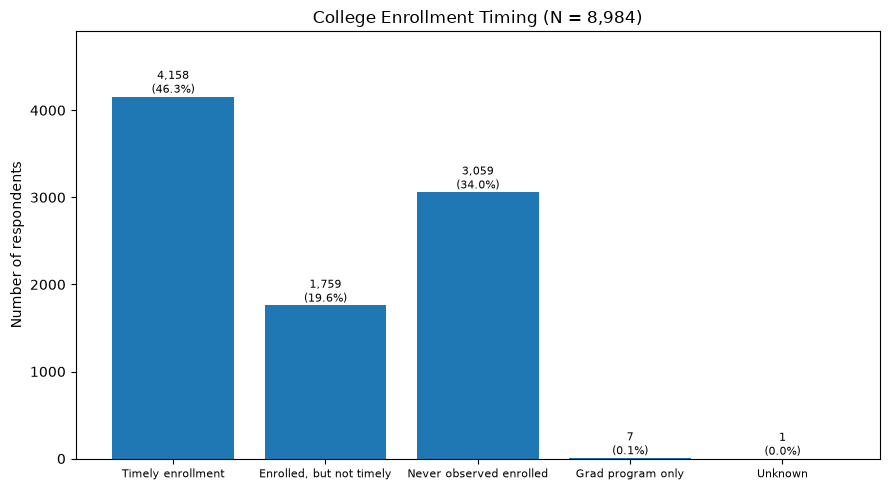

In [289]:
# ============================================================
# ENROLLMENT TIMING CATEGORY
# ============================================================

TIMELY_ORDER = [
    "Timely enrollment",
    "Enrolled, but not timely",
    "Never observed enrolled",
    "Grad program only",
    "Unknown",
]

data["timely_category"] = np.select(
    [
        data["timely_college"].eq(1),
        data["college_history"].eq("Enrolled") & data["timely_college"].eq(0),
        data["college_history"].eq("Never observed enrolled"),
        data["college_history"].eq("Grad program only"),
    ],
    [
        "Timely enrollment",
        "Enrolled, but not timely",
        "Never observed enrolled",
        "Grad program only",
    ],
    default="Unknown",
)

summary = data["timely_category"].value_counts().reindex(TIMELY_ORDER, fill_value=0)
print(summary.to_string())

labeled_bar(summary, f"College Enrollment Timing (N = {len(data):,})")

## Filter data
After this section, there should only contain covariates and treatment at this point.

### Combine Bullying 12-18 across survey years

In [290]:
bullying_cols = [
    "r_victim_of_bullying_12_18_years",        # 1999
    "r_victim_of_bullying_12_18_years_2000",
    "r_victim_of_bullying_12_18_years_2001",
    "r_victim_of_bullying_12_18_years_2002",
    "r_victim_of_bullying_12_18_years_2003",
]

vals = data[bullying_cols]

any_yes = vals.eq(1).any(axis=1)
# -4 = valid skip (not administered that round) - excluded from "bad" on its
# own, but if EVERY round is -4 there's no real information at all, so that
# case is routed to unknown too rather than defaulting to 0.
any_bad_missing = vals.isin([-1, -2, -3, -5]).any(axis=1)
all_skipped = vals.eq(-4).all(axis=1)

data["r_victim_of_bullying_12_18_years"] = np.select(
    [any_yes, any_bad_missing, all_skipped],
    [1, np.nan, np.nan],
    default=0,
)

data = data.drop(columns=[c for c in bullying_cols
                          if c != "r_victim_of_bullying_12_18_years"])

print(data["r_victim_of_bullying_12_18_years"].value_counts(dropna=False).to_string())
print()
print("why unknown, broken out:")
print(pd.Series({
    "bad missing code (-1/-2/-3/-5) present": int(any_bad_missing.sum()),
    "all 5 rounds valid-skip (-4), no info at all": int((all_skipped & ~any_bad_missing).sum()),
}).to_string())

r_victim_of_bullying_12_18_years
0.0    6060
NaN    2025
1.0     899

why unknown, broken out:
bad missing code (-1/-2/-3/-5) present          2197
all 5 rounds valid-skip (-4), no info at all       0


### Earliest arrest age (from date)

In [291]:
# Convert earliest arrest date (YYYYMM) to datetime
data["earliest_arrest_date_dt"] = pd.to_datetime(
    data["earliest_arrest_date"].astype("Int64").astype(str),
    format="%Y%m",
    errors="coerce"
)

# Calculate age at earliest arrest
data["earliest_arrest_age"] = (
    data["earliest_arrest_date_dt"].dt.year
    - data["birth_year"]
    - (
        data["earliest_arrest_date_dt"].dt.month < data["birth_month"]
    )
)

# Make age missing if arrest date or birth information is missing
data.loc[
    data["earliest_arrest_date_dt"].isna()
    | data["birth_year"].isna()
    | data["birth_month"].isna(),
    "earliest_arrest_age"
] = np.nan

# Binary indicator: 1 if earliest arrest was before age 18, 0 otherwise
data["earliest_arrest_before_18"] = (
    data["earliest_arrest_age"] < 18
).astype(int)

/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/1338669156.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["earliest_arrest_date_dt"] = pd.to_datetime(
/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/1338669156.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["earliest_arrest_age"] = (
/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/1338669156.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti

### Combine Race/Ethnicity responses to these categories:
White, Black, Hispanic, Asian, Other

In [292]:
# --- adjust these two names to match your actual renamed columns -----------
HISPANIC_COL = "ethnicity"      # 1 = Yes, 0 = No
RACE_COL = "race"               # 1 White, 2 Black, 3 Am.Indian/Eskimo/Aleut, 4 Asian/PI, 5 Something else
OLD_COMBINED_COL = "race_ethnicity_survey"  # 1 Black, 2 Hispanic, 3 Mixed Race, non-Hisp., 4 Non-Black/non-Hisp.

hispanic = data[HISPANIC_COL]
race = data[RACE_COL]

race_5cat = pd.Series(np.nan, index=data.index, dtype=object)
race_5cat[race.isin([3, 5])] = "Other"    # Am. Indian/Eskimo/Aleut + "something else"
race_5cat[race.eq(4)] = "Asian"
race_5cat[race.eq(2)] = "Black"
race_5cat[race.eq(1)] = "White"
race_5cat[hispanic.eq(1)] = "Hispanic"    # overrides race - assigned last
race_5cat = race_5cat.fillna("Other")

data = data.drop(columns=[HISPANIC_COL, RACE_COL, OLD_COMBINED_COL])
data["race_ethnicity"] = race_5cat

print(data["race_ethnicity"].value_counts(dropna=False).to_string())

race_ethnicity
White       4413
Black       2334
Hispanic    1899
Other        182
Asian        156


/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/2172650215.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["race_ethnicity"] = race_5cat


### Fix ASVAB score percentiles
Change formatting to be percentile (e.g. 15000 --> 15.000)

In [293]:
data['asvab_math_verbal_score_percent'] = data['asvab_math_verbal_score_percent'] / 1000

In [294]:
for col in data.columns:
    print(col)

college_status_1997_01
college_status_1997_02
college_status_1997_03
college_status_1997_04
college_status_1997_05
college_status_1997_06
college_status_1997_07
college_status_1997_08
college_status_1997_09
college_status_1997_10
college_status_1997_11
college_status_1997_12
college_status_1998_01
college_status_1998_02
college_status_1998_03
college_status_1998_04
college_status_1998_05
college_status_1998_06
college_status_1998_07
college_status_1998_08
college_status_1998_09
college_status_1998_10
college_status_1998_11
college_status_1998_12
college_status_1999_01
college_status_1999_02
college_status_1999_03
college_status_1999_04
college_status_1999_05
college_status_1999_06
college_status_1999_07
college_status_1999_08
college_status_1999_09
college_status_1999_10
college_status_1999_11
college_status_1999_12
college_status_2000_01
college_status_2000_02
college_status_2000_03
college_status_2000_04
college_status_2000_05
college_status_2000_06
college_status_2000_07
college_sta

In [295]:
filtered_data = data[[
    'respondent_id', # IDENTIFIER DO NOT USE AS A COVARIATE
    'timely_college', # TREATMENT
    'earliest_arrest_before_18',
    'total_number_of_incarcerations',
    'r_threatened_to_be_hurt_at_school',
    'r_in_a_fight_at_school',
    'days_r_absent_from_school',
    'teachers_good',
    'discipline_is_fair_agree_disagree',
    'percent_of_peers_who_smoke',
    'percent_of_peers_who_get_drunk_1_times_a_month',
    'percent_of_peers_belong_to_a_gang',
    'percent_of_peers_who_have_had_sex',
    'bullying_victim_before_age_12',
    'r_victim_of_bullying_12_18_years',
    'sex',
    'r_ever_live_through_hard_times',
    'household_net_worth',
    'household_size',
    'biological_father_education',
    'biological_mother_education',
    'race_ethnicity',
    'asvab_math_verbal_score_percent',
    'mother_serve_prison_sentence',
    'father_serve_prison_sentence'
]]

In [296]:
print(filtered_data.columns)

Index(['respondent_id', 'timely_college', 'earliest_arrest_before_18',
       'total_number_of_incarcerations', 'r_threatened_to_be_hurt_at_school',
       'r_in_a_fight_at_school', 'days_r_absent_from_school', 'teachers_good',
       'discipline_is_fair_agree_disagree', 'percent_of_peers_who_smoke',
       'percent_of_peers_who_get_drunk_1_times_a_month',
       'percent_of_peers_belong_to_a_gang',
       'percent_of_peers_who_have_had_sex', 'bullying_victim_before_age_12',
       'r_victim_of_bullying_12_18_years', 'sex',
       'r_ever_live_through_hard_times', 'household_net_worth',
       'household_size', 'biological_father_education',
       'biological_mother_education', 'race_ethnicity',
       'asvab_math_verbal_score_percent', 'mother_serve_prison_sentence',
       'father_serve_prison_sentence'],
      dtype='str')


In [297]:
# Data with only covariates and treatment, no outcome (X and Z, no Y)
filtered_data.to_csv(root_dir + "/Data and Resources/filtered_data_no_outcome.csv", index=False)

In [298]:
# Full data, not formatted
data.to_csv(root_dir + "/Data and Resources/full_data.csv", index=False)

# Create Outcome 
(victimization 18-24, caveated on post-college enrollment)

In [299]:
victim_cols = ["violent_victim_2002", "violent_victim_2007", "violent_victim_2008", "violent_victim_2009", "violent_victim_2013"]

victim_data = data[victim_cols].apply(pd.to_numeric, errors="coerce")
reported_yes = (victim_data == 1).any(axis=1)
has_response = ((victim_data == 0) | (victim_data == 1)).any(axis=1)

data["victim_ever"] = pd.Series(pd.NA, index=data.index, dtype="Int64") # fills everything NA first
# so if not a valid response or 1 then will stay NA
data.loc[has_response, "victim_ever"] = 0
data.loc[reported_yes, "victim_ever"] = 1

/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/635687344.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["victim_ever"] = pd.Series(pd.NA, index=data.index, dtype="Int64") # fills everything NA first


In [300]:
victim_age_cols = [
    "age_at_violent_victimization_2002",
    "age_at_violent_victimization_2007",
    "age_at_violent_victimization_2008",
    "age_at_violent_victimization_2009",
    "age_at_violent_victimization_2013"
]

def collect_victimization_ages(row):
    ages = []

    for col in victim_age_cols:
        age = row[col]

        # Keep valid reported ages only
        if pd.notna(age) and age > 0:
            ages.append(int(age))

    return ages

data["victimization_ages"] = data.apply(
    collect_victimization_ages,
    axis=1
)

/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/1844425983.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["victimization_ages"] = data.apply(


In [301]:
data["ever_enrolled"] = ((data["college_history"] == "Enrolled") | (data["college_history"] == "Grad program only")).astype(int)

/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/3613580751.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["ever_enrolled"] = ((data["college_history"] == "Enrolled") | (data["college_history"] == "Grad program only")).astype(int)


In [302]:
data["college_history"].value_counts()

college_history
Enrolled                   5918
Never observed enrolled    3059
Grad program only             7
Name: count, dtype: int64

In [303]:
def create_outcome(row):
    ages = row["victimization_ages"]
    enrolled = row["ever_enrolled"]
    enrollment_age = row["age_at_first_college"]
    victim_ever = row["victim_ever"]

    # Missing victimization information
    if pd.isna(victim_ever):
        return pd.Series({
            "Y": pd.NA,
            "prior_victimization": pd.NA,
            "same_age_as_enrollment": pd.NA,

        })

    # Never reported victimization
    if victim_ever == 0:
        return pd.Series({
            "Y": 0,
            "prior_victimization": 0,
            "same_age_as_enrollment": 0,

        })

    # Make sure victimization ages are stored as a list
    if not isinstance(ages, list):
        valid_ages = []

    else:
        valid_ages = [
            age for age in ages
            if pd.notna(age) and age > 0
        ]

    # Reported victimization, but no valid age is available
    if len(valid_ages) == 0:
        return pd.Series({
            "Y": pd.NA,
            "prior_victimization": pd.NA,
            "same_age_as_enrollment": pd.NA,
        })

    # Missing college-enrollment status
    if pd.isna(enrolled):
        return pd.Series({
            "Y": pd.NA,
            "prior_victimization": pd.NA,
            "same_age_as_enrollment": pd.NA,
        })

    # --------------------------------------------------
    # Never enrolled
    # --------------------------------------------------

    if enrolled == 0:

        # Victimized during the outcome period
        during_18_24 = any(
            18 <= age <= 24
            for age in valid_ages
        )

        # For never-enrolled people, prior means before age 18
        before_18 = any(
            age < 18
            for age in valid_ages
        )

        return pd.Series({
            "Y": int(during_18_24),
            "prior_victimization": int(before_18),
            "same_age_as_enrollment": 0,
        })

    # --------------------------------------------------
    # Enrolled
    # --------------------------------------------------

    # Enrolled, but first enrollment age is unavailable
    if pd.isna(enrollment_age):
        return pd.Series({
            "Y": pd.NA,
            "prior_victimization": pd.NA,
            "same_age_as_enrollment": pd.NA,
        })

    # Victimization before first enrollment
    prior = any(
        age < enrollment_age
        for age in valid_ages
    )

    # Victimization at the same age as first enrollment
    same_age = any(
        age == enrollment_age
        for age in valid_ages
    )

    # Victimization after enrollment during ages 18–24
    after_enrollment_18_24 = any(
        age > enrollment_age
        and 18 <= age <= 24
        for age in valid_ages
    )

    # Definite qualifying outcome
    if after_enrollment_18_24:
        outcome = 1
    # Victimization only known to be at the same age
    elif same_age:
        outcome = pd.NA

    else:
        outcome = 0

    return pd.Series({
        "Y": outcome,
        "prior_victimization": int(prior),
        "same_age_as_enrollment": int(same_age),
    })

In [304]:
outcome_columns = [
    "Y",
    "prior_victimization",
    "same_age_as_enrollment",
]

data[outcome_columns] = data.apply(
    create_outcome,
    axis=1
)

for col in outcome_columns:
    data[col] = data[col].astype("Int64")

/var/folders/sw/wmlbswl578s997jghc7ckfyw0000gn/T/ipykernel_69522/3452904402.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[outcome_columns] = data.apply(


In [305]:
print('\n'.join(data.columns))

college_status_1997_01
college_status_1997_02
college_status_1997_03
college_status_1997_04
college_status_1997_05
college_status_1997_06
college_status_1997_07
college_status_1997_08
college_status_1997_09
college_status_1997_10
college_status_1997_11
college_status_1997_12
college_status_1998_01
college_status_1998_02
college_status_1998_03
college_status_1998_04
college_status_1998_05
college_status_1998_06
college_status_1998_07
college_status_1998_08
college_status_1998_09
college_status_1998_10
college_status_1998_11
college_status_1998_12
college_status_1999_01
college_status_1999_02
college_status_1999_03
college_status_1999_04
college_status_1999_05
college_status_1999_06
college_status_1999_07
college_status_1999_08
college_status_1999_09
college_status_1999_10
college_status_1999_11
college_status_1999_12
college_status_2000_01
college_status_2000_02
college_status_2000_03
college_status_2000_04
college_status_2000_05
college_status_2000_06
college_status_2000_07
college_sta

In [306]:
final_data = data[[
    'respondent_id', # IDENTIFIER DO NOT USE AS A COVARIATE
    'timely_college', # TREATMENT
    'Y', # OUTCOME
    # == COVARIATES ALL BELOW THIS LINE ==
    'earliest_arrest_before_18',
    'total_number_of_incarcerations',
    'r_threatened_to_be_hurt_at_school',
    'r_in_a_fight_at_school',
    'days_r_absent_from_school',
    'teachers_good',
    'discipline_is_fair_agree_disagree',
    'percent_of_peers_who_smoke',
    'percent_of_peers_who_get_drunk_1_times_a_month',
    'percent_of_peers_belong_to_a_gang',
    'percent_of_peers_who_have_had_sex',
    'bullying_victim_before_age_12',
    'r_victim_of_bullying_12_18_years',
    'sex',
    'r_ever_live_through_hard_times',
    'household_net_worth',
    'household_size',
    'biological_father_education',
    'biological_mother_education',
    'race_ethnicity',
    'asvab_math_verbal_score_percent',
    'mother_serve_prison_sentence',
    'father_serve_prison_sentence'
]]

In [307]:
final_data = final_data.rename(columns={'Y': 'violent_victimization_18_24'})
final_data.head(10)

,respondent_id,timely_college,violent_victimization_18_24,earliest_arrest_before_18,total_number_of_incarcerations,r_threatened_to_be_hurt_at_school,r_in_a_fight_at_school,days_r_absent_from_school,teachers_good,discipline_is_fair_agree_disagree,percent_of_peers_who_smoke,percent_of_peers_who_get_drunk_1_times_a_month,percent_of_peers_belong_to_a_gang,percent_of_peers_who_have_had_sex,bullying_victim_before_age_12,r_victim_of_bullying_12_18_years,sex,r_ever_live_through_hard_times,household_net_worth,household_size,biological_father_education,biological_mother_education,race_ethnicity,asvab_math_verbal_score_percent,mother_serve_prison_sentence,father_serve_prison_sentence
0,1,0.0,0,0,0,0,0,2,1,2,5,4,1,3,0,0.0,2,0,-3,6,16,8,White,45.070,0,0
1,2,1.0,0,0,0,0,0,3,2,1,1,4,1,-4,1,0.0,1,-4,-4,4,17,15,Hispanic,58.483,0,0
2,3,0.0,0,0,0,0,0,1,2,2,4,2,1,-4,1,0.0,2,0,10200,2,-3,12,Hispanic,27.978,0,0
3,4,1.0,0,0,0,0,0,4,2,2,5,5,4,4,0,0.0,2,0,-1500,2,12,12,Hispanic,37.012,0,0
4,5,0.0,1,0,0,0,3,3,2,3,3,1,2,1,0,0.0,1,0,-3,4,12,12,Hispanic,-0.004,0,0
5,6,1.0,0,0,0,0,0,21,2,2,5,3,3,5,0,0.0,2,0,7500,5,-3,12,Hispanic,22.001,0,0
6,7,0.0,0,1,0,0,0,17,2,2,5,2,1,-4,0,NaN,1,0,7500,5,-3,12,Hispanic,3.585,-5,-5
7,8,1.0,0,0,0,0,0,0,1,1,2,1,-2,-2,0,0.0,2,0,-3,5,6,12,White,-0.004,-5,-5
8,9,0.0,0,0,0,0,0,5,1,2,2,3,1,-2,0,0.0,1,0,-3,5,6,12,White,-0.004,0,0
9,10,1.0,0,0,0,0,0,3,1,2,1,1,1,-4,0,0.0,1,0,-3,5,6,12,White,-0.004,-5,-5


In [308]:
# Final dataset to be used for analysis, with treatment, outcome, and covariates
final_data.to_csv(root_dir + "/Data and Resources/final_data.csv", index=False)

In [309]:
print("Done")

Done
